In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

df.shape

(284807, 31)

In [3]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(1081)

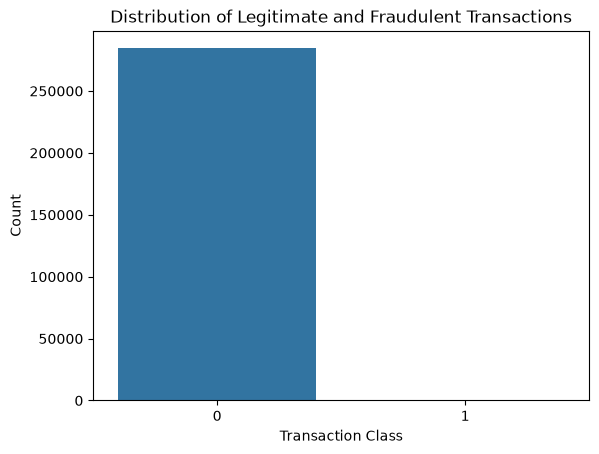

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()

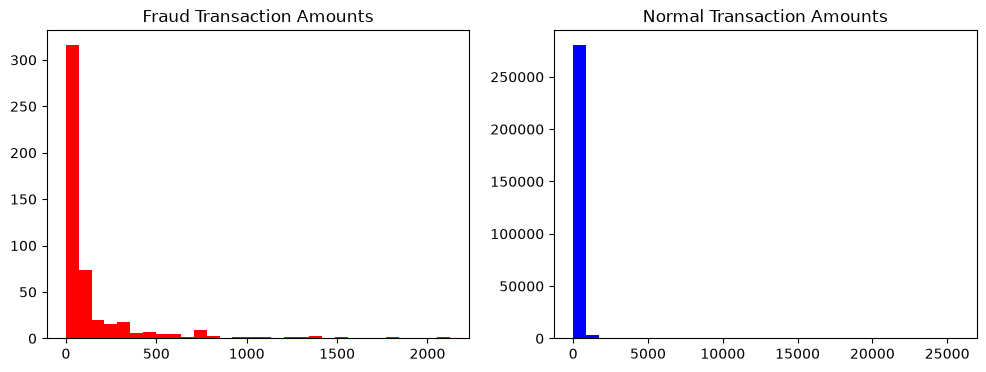

Fraud amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [13]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(fraud['Amount'], bins=30, color='red')
ax[0].set_title('Fraud Transaction Amounts')
ax[1].hist(normal['Amount'], bins=30, color='blue')
ax[1].set_title('Normal Transaction Amounts')
plt.show()

print("Fraud amount stats:")
print(fraud['Amount'].describe())
print("\nNormal amount stats:")
print(normal['Amount'].describe())

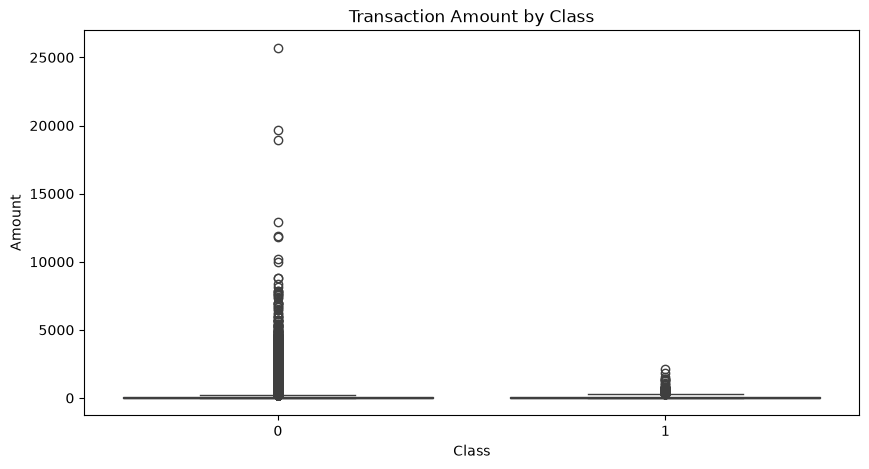

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

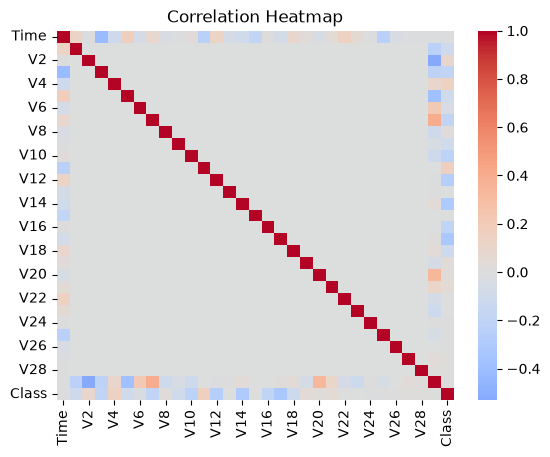

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [ ]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Which features correlate most with fraud?
print(corr['Class'].sort_values(ascending=False))

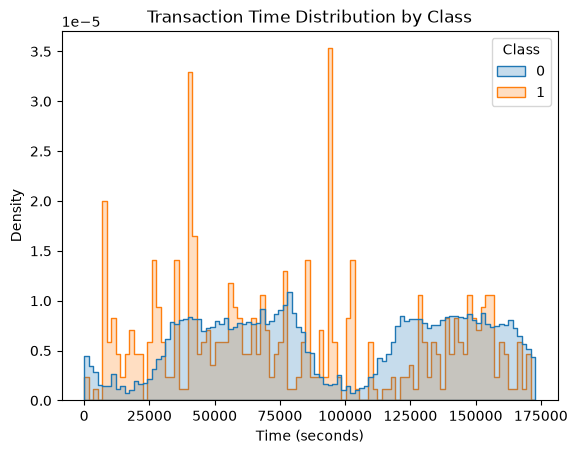

In [20]:
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.show()

In [21]:
correlations = df.corr(numeric_only=True)["Class"].drop("Class")

correlations.abs().sort_values(ascending=False).head(10)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

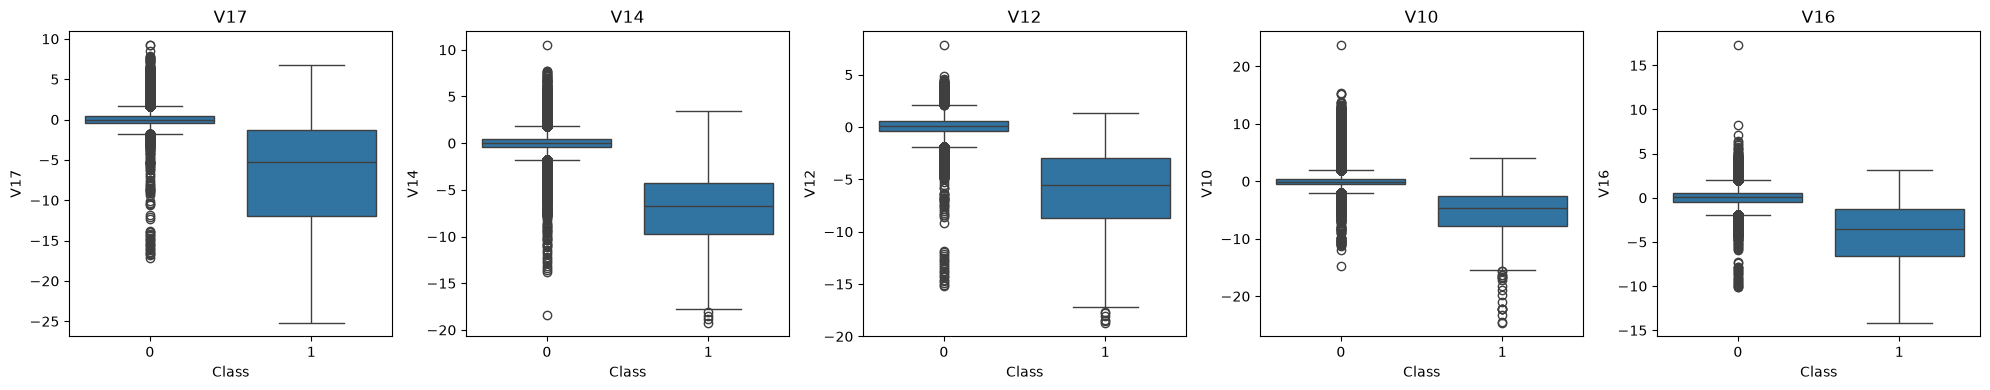

In [24]:
top_features = ["V17", "V14", "V12", "V10", "V16"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feature in zip(axes, top_features):
    sns.boxplot(data=df, x="Class", y=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Time', 'Amount'], axis=1)

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # <-- this is the important part
)

print("Train fraud %:", y_train.mean() * 100)
print("Test fraud %:", y_test.mean() * 100)

Train fraud %: 0.17292457591783889
Test fraud %: 0.17204452090867595


In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of fraud

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Average Precision Score:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56851    13]
 [   35    63]]
ROC AUC Score: 0.9572835078037969
Average Precision Score: 0.7439486441557351


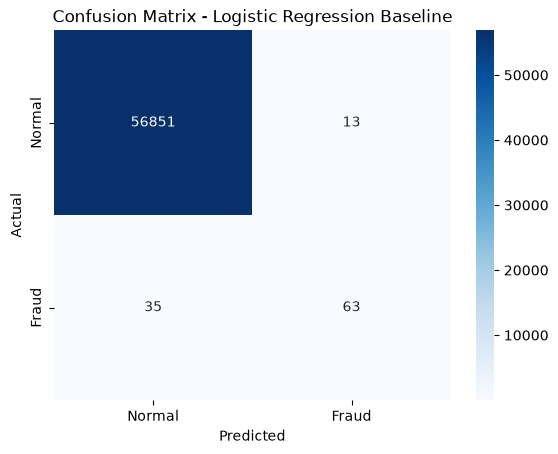

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.show()

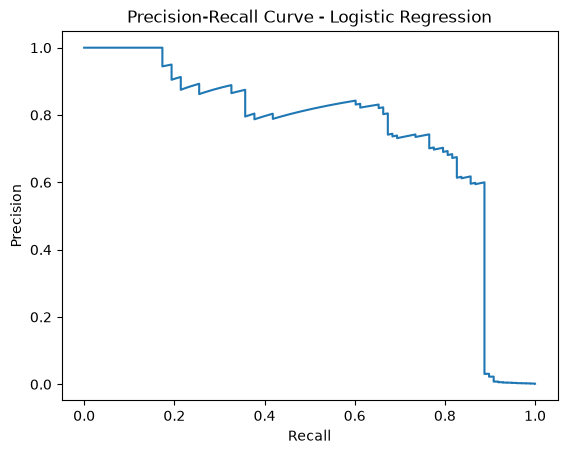

In [30]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1          # use all CPU cores, speeds up training
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8607506769591988
ROC-AUC: 0.952793291979144


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',   # avoids a warning, standard for binary classification
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud']))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.7813171412660339
ROC-AUC: 0.9219230021074272


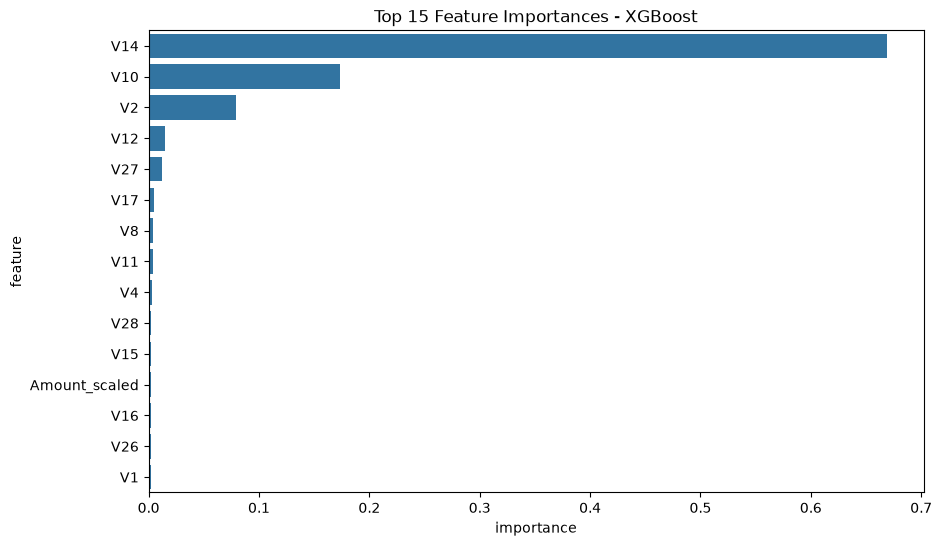

   feature  importance
13     V14    0.668751
9      V10    0.173469
1       V2    0.079504
11     V12    0.015174
26     V27    0.011785
16     V17    0.005272
7       V8    0.004353
10     V11    0.004201
3       V4    0.003114
27     V28    0.002485


In [36]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances - XGBoost')
plt.show()

print(importances.head(10))

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'PR-AUC': [
        average_precision_score(y_test, y_proba),      # from Phase 2, LR
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})
print(results)

# Save it so you don't lose it
results.to_csv('model_comparison.csv', index=False)

                 Model    PR-AUC   ROC-AUC
0  Logistic Regression  0.743949  0.957284
1        Random Forest  0.860751  0.952793
2              XGBoost  0.781317  0.921923


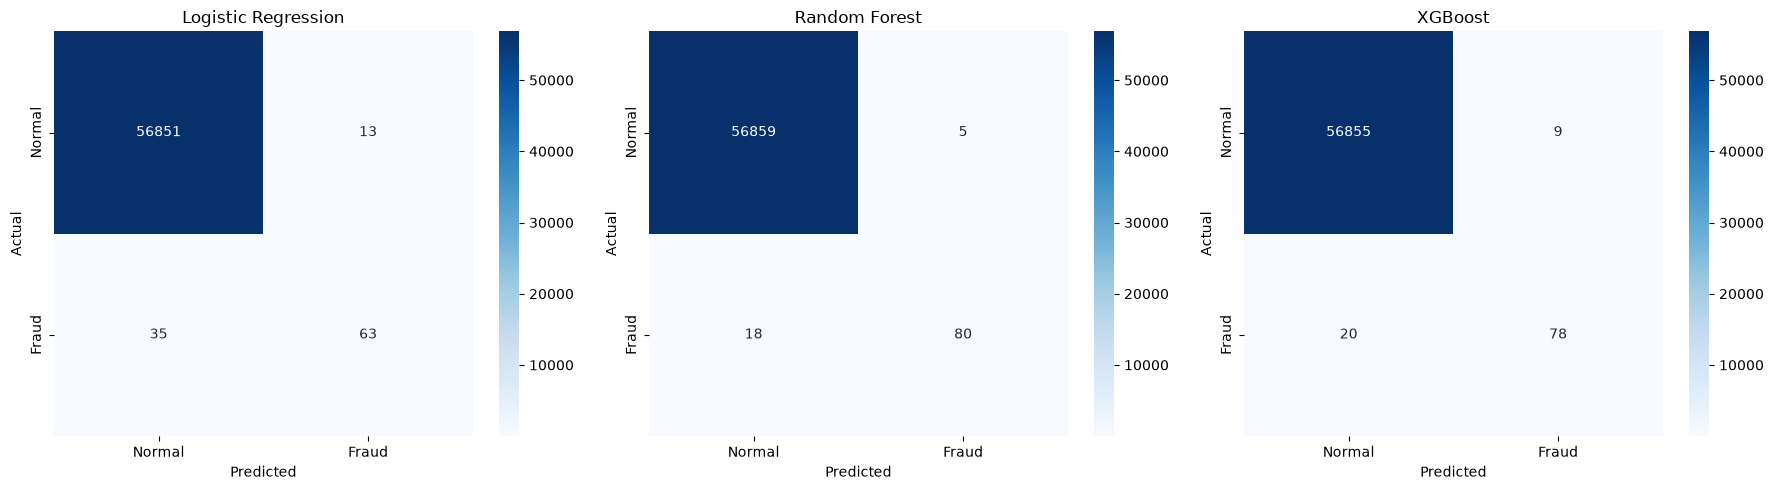

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in zip(
    axes,
    [y_pred, y_pred_rf, y_pred_xgb],
    ['Logistic Regression', 'Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [39]:
print("RF train PR-AUC:", average_precision_score(y_train, rf_model.predict_proba(X_train)[:, 1]))
print("RF test PR-AUC:", average_precision_score(y_test, y_proba_rf))

RF train PR-AUC: 1.0
RF test PR-AUC: 0.8607506769591988


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression with class_weight
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted.fit(X_train, y_train)
y_proba_lr_w = lr_weighted.predict_proba(X_test)[:, 1]

# Random Forest with class_weight
rf_weighted = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       random_state=42, n_jobs=-1)
rf_weighted.fit(X_train, y_train)
y_proba_rf_w = rf_weighted.predict_proba(X_test)[:, 1]

print("LR weighted PR-AUC:", average_precision_score(y_test, y_proba_lr_w))
print("RF weighted PR-AUC:", average_precision_score(y_test, y_proba_rf_w))

LR weighted PR-AUC: 0.7189463752156903
RF weighted PR-AUC: 0.8501966632467751


In [41]:
from xgboost import XGBClassifier

# scale_pos_weight = (# negative samples) / (# positive samples)
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Weight ratio:", weight_ratio)

xgb_weighted = XGBClassifier(n_estimators=100, scale_pos_weight=weight_ratio,
                               random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_weighted.fit(X_train, y_train)
y_proba_xgb_w = xgb_weighted.predict_proba(X_test)[:, 1]

print("XGB weighted PR-AUC:", average_precision_score(y_test, y_proba_xgb_w))

Weight ratio: 577.2868020304569
XGB weighted PR-AUC: 0.8727247933674632


In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [43]:
# Train models on SMOTE'd data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_proba_lr_s = lr_smote.predict_proba(X_test)[:, 1]

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_proba_rf_s = rf_smote.predict_proba(X_test)[:, 1]

print("LR SMOTE PR-AUC:", average_precision_score(y_test, y_proba_lr_s))
print("RF SMOTE PR-AUC:", average_precision_score(y_test, y_proba_rf_s))

LR SMOTE PR-AUC: 0.7248611768135256
RF SMOTE PR-AUC: 0.8677902925456846


In [44]:
comparison = pd.DataFrame({
    'Method': ['Baseline LR', 'Weighted LR', 'SMOTE LR',
               'Baseline RF', 'Weighted RF', 'SMOTE RF'],
    'PR-AUC': [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, y_proba_lr_w),
        average_precision_score(y_test, y_proba_lr_s),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_rf_w),
        average_precision_score(y_test, y_proba_rf_s),
    ]
})
print(comparison.sort_values('PR-AUC', ascending=False))

        Method    PR-AUC
5     SMOTE RF  0.867790
3  Baseline RF  0.860751
4  Weighted RF  0.850197
0  Baseline LR  0.743949
2     SMOTE LR  0.724861
1  Weighted LR  0.718946


In [45]:
results = pd.read_csv('model_comparison.csv')
new_rows = pd.DataFrame({
    'Model': comparison['Method'],
    'PR-AUC': comparison['PR-AUC'],
    'ROC-AUC': [None]*6  # fill in if you want, using roc_auc_score similarly
})
results = pd.concat([results, new_rows], ignore_index=True)
results.to_csv('model_comparison.csv', index=False)

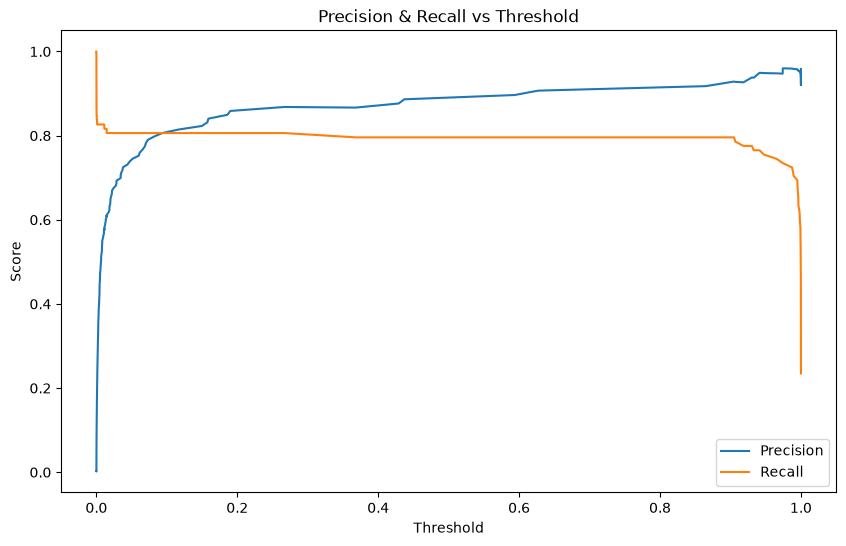

In [46]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)  # use your best model

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision & Recall vs Threshold')
plt.show()

In [47]:
target_recall = 0.90  # "we want to catch at least 90% of fraud"

# Find the threshold where recall first drops below target
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
best_idx = valid_idx[-1]  # last index where recall still >= target
best_threshold = thresholds[best_idx]

print(f"Threshold for {target_recall*100}% recall: {best_threshold:.4f}")
print(f"Precision at this threshold: {precisions[best_idx]:.4f}")

Threshold for 90.0% recall: 0.0000
Precision at this threshold: 0.0165


Cost-optimal threshold: 0.0111


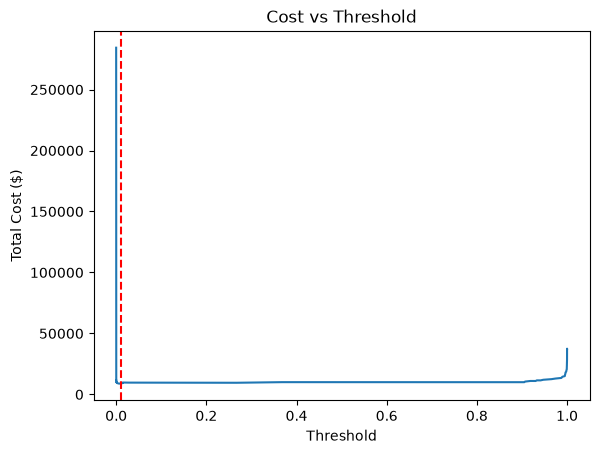

In [49]:
cost_fn = 500   # cost of missing a fraud (false negative) — avg fraud loss, made up, adjust as you like
cost_fp = 5     # cost of a false alarm (false positive) — e.g. customer service time, annoyance

costs = []
for t in thresholds:
    preds_t = (y_proba_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, preds_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

best_threshold_cost = thresholds[np.argmin(costs)]
print(f"Cost-optimal threshold: {best_threshold_cost:.4f}")

plt.plot(thresholds, costs)
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Cost vs Threshold')
plt.axvline(best_threshold_cost, color='red', linestyle='--')
plt.show()

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.58      0.83      0.68        98

    accuracy                           1.00     56962
   macro avg       0.79      0.91      0.84     56962
weighted avg       1.00      1.00      1.00     56962



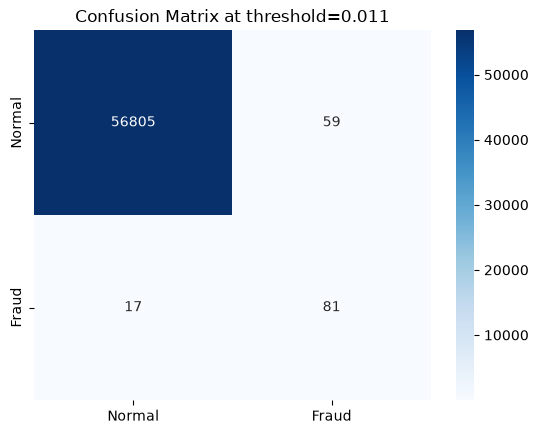

In [50]:
chosen_threshold = best_threshold_cost  # or best_threshold from Option A

y_pred_tuned = (y_proba_xgb >= chosen_threshold).astype(int)

print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix at threshold={chosen_threshold:.3f}')
plt.show()

In [51]:
def evaluate_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    recall = tp / (tp + fn) if (tp+fn) > 0 else 0
    return {'threshold': threshold, 'precision': precision, 'recall': recall,
            'false_negatives': fn, 'false_positives': fp}

print(evaluate_at_threshold(y_test, y_proba_xgb, 0.5))          # default
print(evaluate_at_threshold(y_test, y_proba_xgb, chosen_threshold))  # tuned

{'threshold': 0.5, 'precision': np.float64(0.896551724137931), 'recall': np.float64(0.7959183673469388), 'false_negatives': np.int64(20), 'false_positives': np.int64(9)}
{'threshold': np.float32(0.011077398), 'precision': np.float64(0.5785714285714286), 'recall': np.float64(0.826530612244898), 'false_negatives': np.int64(17), 'false_positives': np.int64(59)}


In [52]:
from sklearn.ensemble import IsolationForest

# contamination = expected proportion of outliers (roughly your fraud rate)
fraud_rate = y_train.mean()
print("Fraud rate:", fraud_rate)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)

# Train on ALL training data (no labels used in fit)
iso_forest.fit(X_train)

# Predict: -1 = anomaly (flagged as fraud), 1 = normal
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # convert to 0/1 to match your labels

# Get anomaly scores (lower = more anomalous) and flip sign so higher = more fraud-like
y_scores_iso = -iso_forest.score_samples(X_test)

print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Fraud']))
print("PR-AUC:", average_precision_score(y_test, y_scores_iso))
print("ROC-AUC:", roc_auc_score(y_test, y_scores_iso))

Fraud rate: 0.001729245759178389
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.30      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.1915817001190566
ROC-AUC: 0.9536498828569131


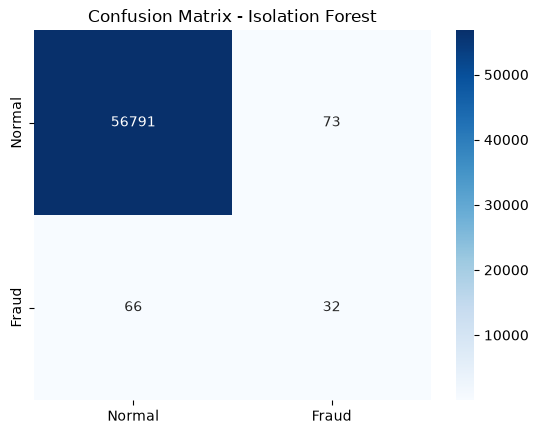

In [53]:
cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

In [54]:
import torch
import torch.nn as nn
import numpy as np

# Train only on normal transactions — same rule as before
X_train_normal = X_train[y_train == 0]
print("Training on", X_train_normal.shape[0], "normal transactions only")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_normal.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

input_dim = X_train_tensor.shape[1]
print("Input dimension:", input_dim)

Training on 227451 normal transactions only
Input dimension: 30


In [55]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 14),
            nn.ReLU(),
            nn.Linear(14, 7),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(7, 14),
            nn.ReLU(),
            nn.Linear(14, 20),
            nn.ReLU(),
            nn.Linear(20, input_dim)   # linear output, no activation
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model_ae = Autoencoder(input_dim)
print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=14, bias=True)
    (3): ReLU()
    (4): Linear(in_features=14, out_features=7, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=7, out_features=14, bias=True)
    (1): ReLU()
    (2): Linear(in_features=14, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=30, bias=True)
  )
)


In [56]:
from torch.utils.data import TensorDataset, DataLoader

# Wrap data in a DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001)

n_epochs = 20
train_losses = []

for epoch in range(n_epochs):
    model_ae.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_ae(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.6f}")

Epoch 1/20 - Loss: 0.657355
Epoch 2/20 - Loss: 0.411265
Epoch 3/20 - Loss: 0.377101
Epoch 4/20 - Loss: 0.349158
Epoch 5/20 - Loss: 0.332183
Epoch 6/20 - Loss: 0.318969
Epoch 7/20 - Loss: 0.306037
Epoch 8/20 - Loss: 0.294497
Epoch 9/20 - Loss: 0.285787
Epoch 10/20 - Loss: 0.278976
Epoch 11/20 - Loss: 0.273515
Epoch 12/20 - Loss: 0.270479
Epoch 13/20 - Loss: 0.267552
Epoch 14/20 - Loss: 0.264750
Epoch 15/20 - Loss: 0.262006
Epoch 16/20 - Loss: 0.259462
Epoch 17/20 - Loss: 0.256956
Epoch 18/20 - Loss: 0.254201
Epoch 19/20 - Loss: 0.251297
Epoch 20/20 - Loss: 0.248413


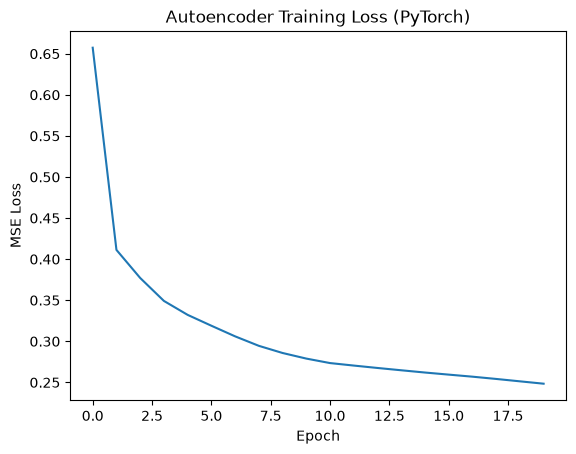

In [57]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss (PyTorch)')
plt.show()

In [58]:
model_ae.eval()  # switches off dropout/batchnorm behavior (not used here, but good habit)

with torch.no_grad():  # no gradients needed for inference, saves memory/speed
    X_test_pred = model_ae(X_test_tensor)
    reconstruction_error = torch.mean((X_test_tensor - X_test_pred) ** 2, dim=1)
    reconstruction_error = reconstruction_error.numpy()  # convert back to numpy for sklearn metrics

from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix

print("PR-AUC:", average_precision_score(y_test, reconstruction_error))
print("ROC-AUC:", roc_auc_score(y_test, reconstruction_error))

PR-AUC: 0.5555675367188162
ROC-AUC: 0.9490411422025197


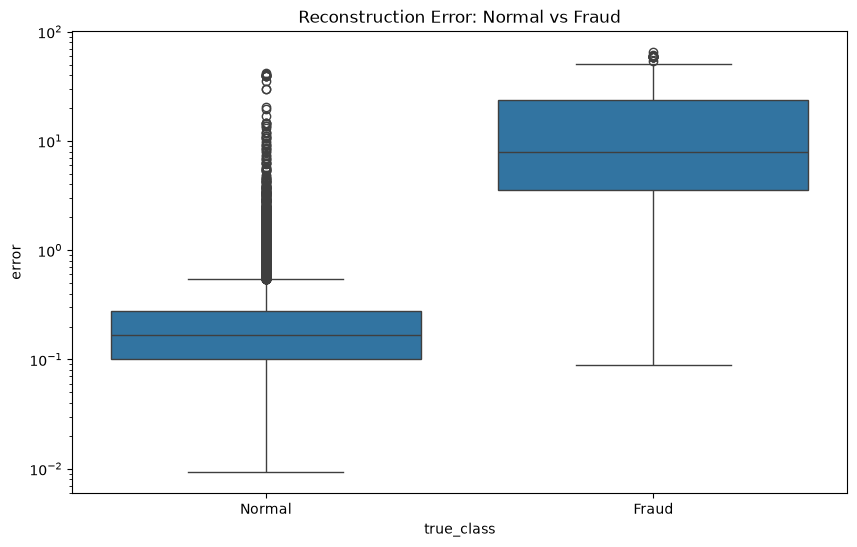

In [59]:
import seaborn as sns
import pandas as pd

error_df = pd.DataFrame({'error': reconstruction_error, 'true_class': y_test.values})

plt.figure(figsize=(10, 6))
sns.boxplot(x='true_class', y='error', data=error_df)
plt.yscale('log')
plt.title('Reconstruction Error: Normal vs Fraud')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.55      0.54      0.54        98

    accuracy                           1.00     56962
   macro avg       0.77      0.77      0.77     56962
weighted avg       1.00      1.00      1.00     56962



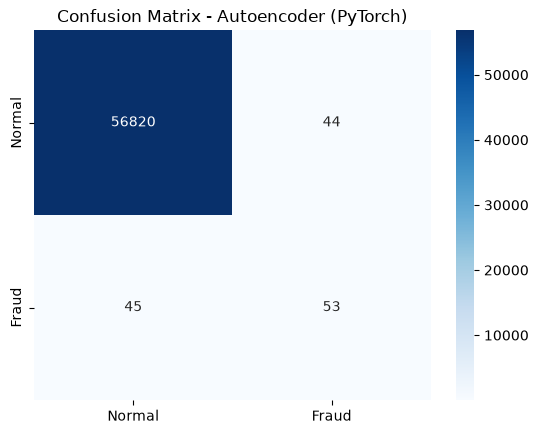

In [60]:
threshold_ae = np.percentile(reconstruction_error, 99.83)  # roughly matches fraud rate
y_pred_ae = (reconstruction_error >= threshold_ae).astype(int)

print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_ae)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Autoencoder (PyTorch)')
plt.show()

In [61]:
import os
os.makedirs('models', exist_ok=True)
torch.save(model_ae.state_dict(), 'models/autoencoder.pth')

# To reload later:
# model_ae = Autoencoder(input_dim)
# model_ae.load_state_dict(torch.load('models/autoencoder.pth'))
# model_ae.eval()